In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

========== PERFORMANCE EVALUATION ==========

NIBLACK METHOD
Sensitivity (Recall): 0.9435071781973625

SAUVOLA METHOD
Sensitivity (Recall): 0.7679049395730522


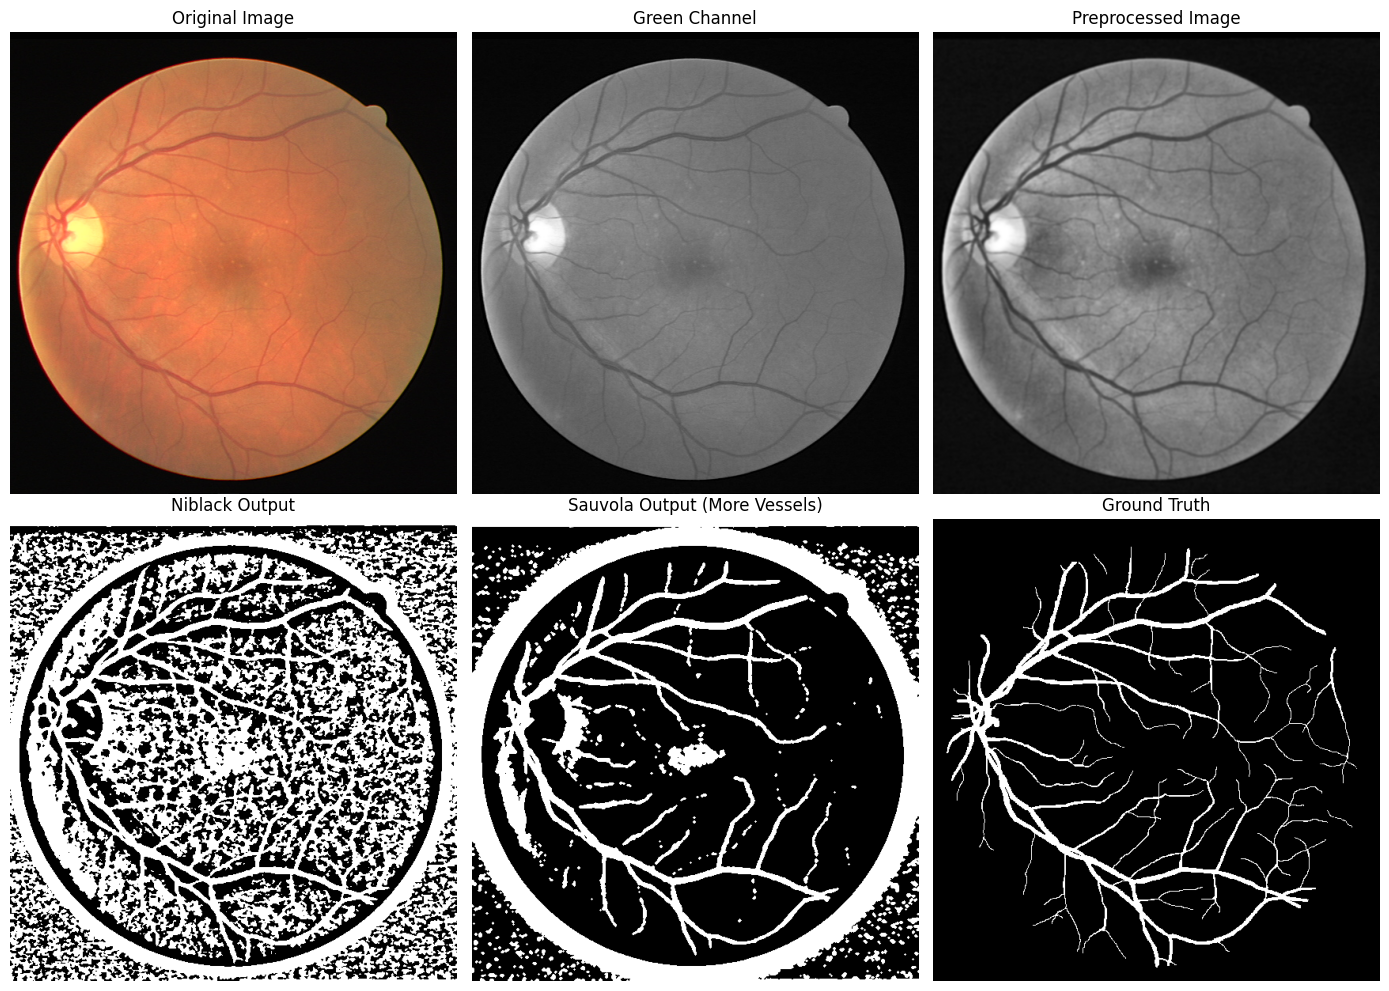

In [2]:
# ============================================================
# RETINAL VESSEL SEGMENTATION USING NIBLACK & SAUVOLA
# EVALUATION USING SENSITIVITY (RECALL)
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
from skimage.morphology import disk, dilation
from PIL import Image

# ------------------------------------------------
# 1. DATASET PATH
# ------------------------------------------------
BASE_PATH = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE"
image_dir = os.path.join(BASE_PATH, "training/images")
mask_dir  = os.path.join(BASE_PATH, "training/1st_manual")

# Select one image
image_name = sorted(os.listdir(image_dir))[0]
image_id = image_name.split("_")[0]
mask_name = f"{image_id}_manual1.gif"

image_path = os.path.join(image_dir, image_name)
mask_path  = os.path.join(mask_dir, mask_name)

# ------------------------------------------------
# 2. LOAD IMAGE AND GROUND TRUTH
# ------------------------------------------------
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gt = np.array(Image.open(mask_path).convert("L"))
gt = (gt > 0).astype(np.uint8)

# ------------------------------------------------
# 3. PREPROCESSING
# ------------------------------------------------
green = image[:, :, 1]

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(green)

smoothed = cv2.GaussianBlur(enhanced, (5, 5), 0)

# ------------------------------------------------
# 4. NIBLACK THRESHOLDING
# ------------------------------------------------
th_niblack = threshold_niblack(
    smoothed,
    window_size=25,
    k=-0.2
)
niblack = smoothed < th_niblack

# ------------------------------------------------
# 5. SAUVOLA THRESHOLDING (MORE INNER VESSELS)
# ------------------------------------------------
th_sauvola = threshold_sauvola(
    smoothed,
    window_size=51,   # larger window
    k=0.12            # lower k → more vessels
)
sauvola = smoothed < th_sauvola

# slight dilation to connect thin vessels
sauvola = dilation(sauvola, disk(1))

# ------------------------------------------------
# 6. EVALUATION USING SENSITIVITY (RECALL)
# ------------------------------------------------
def sensitivity(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    TP = np.logical_and(gt, pred).sum()
    FN = np.logical_and(gt, ~pred).sum()
    return TP / (TP + FN + 1e-8)

sens_niblack = sensitivity(gt, niblack)
sens_sauvola = sensitivity(gt, sauvola)

print("========== PERFORMANCE EVALUATION ==========\n")
print("NIBLACK METHOD")
print("Sensitivity (Recall):", sens_niblack)

print("\nSAUVOLA METHOD")
print("Sensitivity (Recall):", sens_sauvola)

# ------------------------------------------------
# 7. VISUALIZATION
# ------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Green Channel")
plt.imshow(green, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Preprocessed Image")
plt.imshow(smoothed, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Niblack Output")
plt.imshow(niblack, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Sauvola Output (More Vessels)")
plt.imshow(sauvola, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Ground Truth")
plt.imshow(gt, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
